# ZINC Interpolation and Sampling Dynamics

This notebook trains or reloads a ZINC generator, compares endpoint interpolation modes, and sweeps temporary sampling-dynamics settings to inspect their effect on generated molecules.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


PyTorch version: 2.2.2
CUDA available: False


In [2]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc15'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
DATA_LIMIT = 2000
FIT_BATCH_SIZE = 64
MAXIMUM_EPOCHS = 350

# First-pass anti-saturation knobs: keep capacity fixed, increase score signal.
EMBEDDING_DIM = 64
LEARNING_RATE = 2e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.5

# Capacity knobs. Increase only after the dense-signal run still plateaus.
NUMBER_OF_TRANSFORMER_LAYERS = 3
TRANSFORMER_ATTENTION_HEAD_COUNT = 4
TRANSFORMER_DROPOUT = 0.1

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

MODEL_NAME = (
    f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-s{DATA_LIMIT}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [3]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}


ZINC CSV: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/notebooks/datasets/zinc/zinc15.csv
Loaded 2000 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc15-nonstreaming-d64-s2000-b64-lr0-0002-mask0-5-e350 model_dir=/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators


In [4]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc20-nonstreaming-d64-s0-99-b128-e350.pkl'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)

,name,modified,size_mb
0,zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mas...,2026-05-31 01:44,7.9
1,artificial-cycle-path-star-n5000-c5-p3-r2x1-d6...,2026-05-31 01:30,7.9
2,artificial-cycle-path-star-n3000-c5-p3-r2x1-d6...,2026-05-30 20:05,6.8
3,zinc15-nonstreaming-d64-s2000-b64-lr0-0002-mas...,2026-05-30 19:52,6.4
4,zinc15-nonstreaming-d64-s1500-b128-e350.pkl,2026-05-27 18:41,6.1


Loaded graph generator: zinc15-nonstreaming-d64-s2000-b64-lr0-0002-mask0-5-e350.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/zinc15-nonstreaming-d64-s2000-b64-lr0-0002-mask0-5-e350.pkl


Non-streaming ZINC raw samples


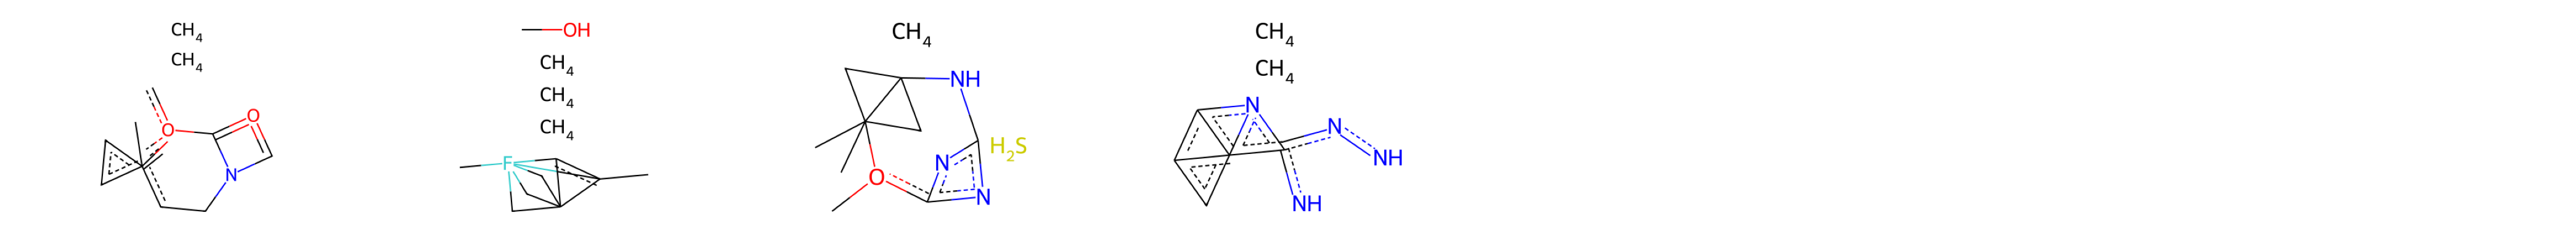

CPU times: user 15.1 s, sys: 1.03 s, total: 16.2 s
Wall time: 22.1 s


In [5]:
%%time
n_samples = 4
raw_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=False,
)

show_molecules(raw_samples, n=n_samples, title='Non-streaming ZINC raw samples')

Non-streaming ZINC ILP samples


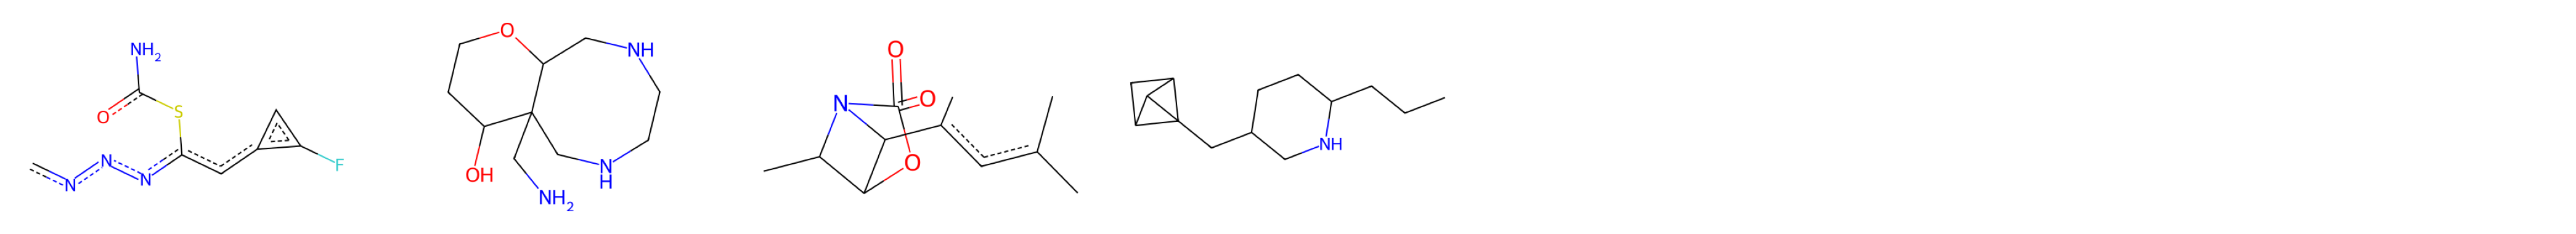

CPU times: user 21.4 s, sys: 2.65 s, total: 24.1 s
Wall time: 2min 4s


In [6]:
%%time
ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
)
show_molecules(ilp_samples, n=n_samples, title='Non-streaming ZINC ILP samples')


Non-streaming ZINC ILP samples


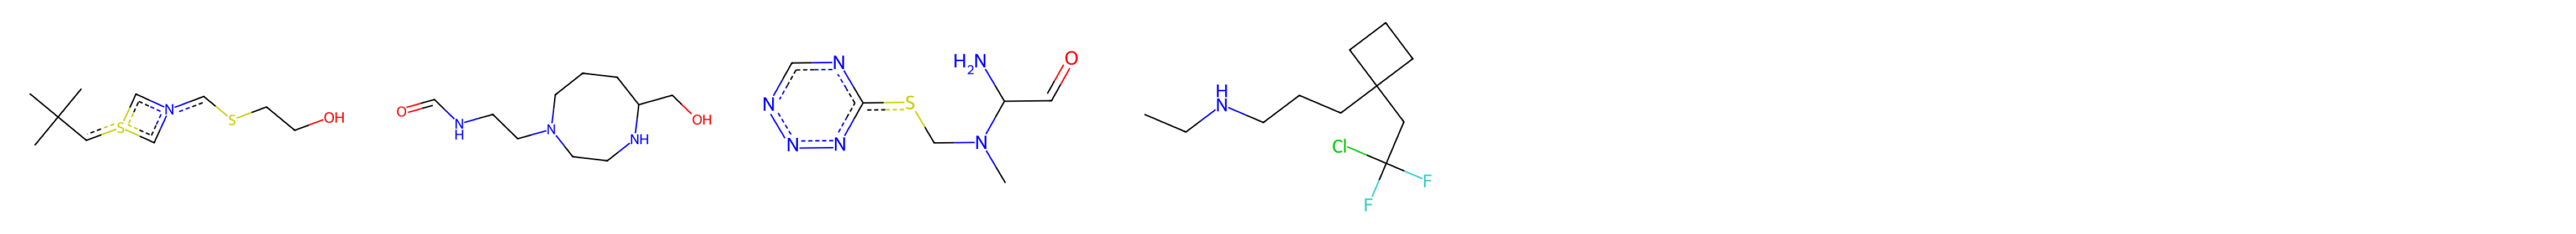

CPU times: user 21.2 s, sys: 4.5 s, total: 25.7 s
Wall time: 1min 19s


In [ ]:
%%time

ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
    use_feasibility_oracle=True,
)
show_molecules(ilp_samples, n=n_samples, title='Non-streaming ZINC ILP samples')

In [ ]:
%%time
graph_generator.use_feasibility_oracle = True

ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=True,
    use_ilp_decoder=True,
)
show_molecules(ilp_samples, n=n_samples, title='Non-streaming ZINC ILP samples')

## Positive Endpoint Interpolation

Select two active molecules at random, interpolate between them, and display the endpoints plus feasible generated molecules.

Endpoint indices: [423, 701]
Selected endpoint molecules


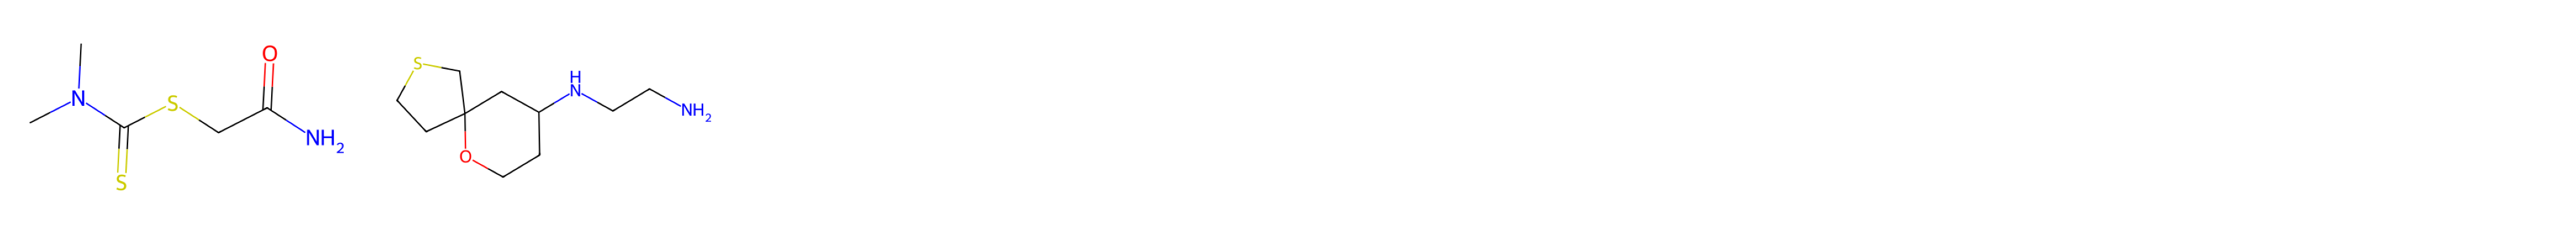

,step,t,target_nodes,target_edges,decoded,mode
0,1,0.25,11,10,True,slerp
1,2,0.50,12,12,True,slerp
2,3,0.75,13,14,True,slerp


Endpoints and generated interpolation molecules


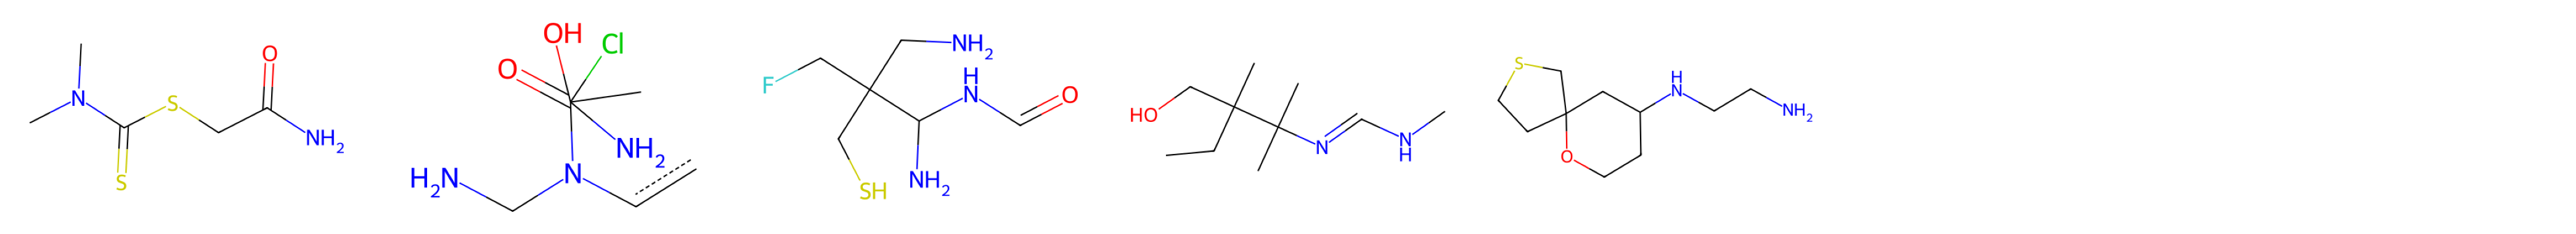

In [18]:
from conditional_node_field_graph_generator.extensions.demo.visualization import sample_positive_endpoint_pair
# Interpolate between two active molecules and decode the intermediate trajectory.
targets = [1]*len(graphs)
selected_indices, selected_targets, endpoint_graph_a, endpoint_graph_b = sample_positive_endpoint_pair(
    graphs,
    targets,
)
print("Endpoint indices:", selected_indices)

show_molecules([endpoint_graph_a, endpoint_graph_b], n=2, title="Selected endpoint molecules")

graph_generator.use_feasibility_oracle = True
interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=False,
)
display(interpolation_result["summary"])

missing_steps = interpolation_result["summary"].loc[
    ~interpolation_result["summary"]["decoded"],
    "step",
].tolist()
if missing_steps:
    print("Interpolation steps rejected by feasibility filtering:", missing_steps)

show_molecules(
    [endpoint_graph_a, *interpolation_result["generated_graphs"], endpoint_graph_b],
    n=len(interpolation_result["generated_graphs"]) + 2,
    title="Endpoints and generated interpolation molecules",
)


## Sampling Dynamics Sweep

Use this cell to compare how the node-field generation dynamics affect interpolation quality. Edit `SAMPLING_DYNAMICS_GRID`, rerun the cell, and compare the decoded molecules plus feasibility summaries.


In [ ]:
from contextlib import contextmanager

SAMPLING_DYNAMICS_GRID = [
    {
        "label": "baseline",
        "sampling_step_size": 0.05,
        "sampling_steps": None,
        "langevin_noise_scale": 0.0,
    },
    {
        "label": "smaller-step-more-steps",
        "sampling_step_size": 0.025,
        "sampling_steps": 200,
        "langevin_noise_scale": 0.0,
    },
    {
        "label": "more-exploration",
        "sampling_step_size": 0.05,
        "sampling_steps": None,
        "langevin_noise_scale": 0.05,
    },
]

SWEEP_INTERPOLATION_K = 3
SWEEP_APPLY_FEASIBILITY_FILTERING = False
SWEEP_USE_FEASIBILITY_ORACLE = True
SWEEP_USE_ILP_DECODER = True
SWEEP_FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 2


def _node_generator(graph_generator):
    node_generator = getattr(graph_generator, "conditional_node_generator_model", None)
    if node_generator is None:
        raise RuntimeError("graph_generator has no conditional_node_generator_model.")
    return node_generator


@contextmanager
def temporary_sampling_dynamics(graph_generator, *, sampling_step_size, sampling_steps, langevin_noise_scale):
    node_generator = _node_generator(graph_generator)
    original_values = {
        "sampling_step_size": getattr(node_generator, "sampling_step_size", None),
        "sampling_steps": getattr(node_generator, "sampling_steps", None),
        "langevin_noise_scale": getattr(node_generator, "langevin_noise_scale", None),
    }
    if sampling_step_size is not None:
        node_generator.sampling_step_size = float(sampling_step_size)
    if sampling_steps is not None:
        node_generator.sampling_steps = int(sampling_steps)
    if langevin_noise_scale is not None:
        node_generator.langevin_noise_scale = float(langevin_noise_scale)
    try:
        yield node_generator
    finally:
        for name, value in original_values.items():
            if value is not None:
                setattr(node_generator, name, value)


def summarize_generation_quality(graph_generator, graphs):
    if not graphs:
        return {
            "decoded": 0,
            "feasible": 0,
            "feasible_rate": 0.0,
            "mean_violations": float("nan"),
            "median_violations": float("nan"),
        }
    feasibility_estimator = getattr(graph_generator, "feasibility_estimator", None)
    if feasibility_estimator is None:
        return {
            "decoded": len(graphs),
            "feasible": None,
            "feasible_rate": None,
            "mean_violations": None,
            "median_violations": None,
        }
    feasible_mask = np.asarray(feasibility_estimator.predict(graphs), dtype=bool)
    if hasattr(feasibility_estimator, "number_of_violations"):
        violations = np.asarray(feasibility_estimator.number_of_violations(graphs), dtype=float)
    else:
        violations = np.where(feasible_mask, 0.0, 1.0)
    return {
        "decoded": len(graphs),
        "feasible": int(feasible_mask.sum()),
        "feasible_rate": float(feasible_mask.mean()),
        "mean_violations": float(np.mean(violations)),
        "median_violations": float(np.median(violations)),
    }


sweep_rows = []
sweep_results = []
for config in SAMPLING_DYNAMICS_GRID:
    label = config["label"]
    print("=" * 80)
    print(
        f"{label}: step_size={config['sampling_step_size']} | "
        f"steps={config['sampling_steps']} | "
        f"langevin_noise={config['langevin_noise_scale']}"
    )
    with temporary_sampling_dynamics(
        graph_generator,
        sampling_step_size=config["sampling_step_size"],
        sampling_steps=config["sampling_steps"],
        langevin_noise_scale=config["langevin_noise_scale"],
    ):
        result = graph_generator.interpolate(
            endpoint_graph_a,
            endpoint_graph_b,
            k=SWEEP_INTERPOLATION_K,
            apply_feasibility_filtering=SWEEP_APPLY_FEASIBILITY_FILTERING,
            feasibility_oracle_candidates_per_attempt=(
                SWEEP_FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT
                if SWEEP_USE_FEASIBILITY_ORACLE
                else 0
            ),
            use_ilp_decoder=SWEEP_USE_ILP_DECODER,
        )
    generated_graphs = result["generated_graphs"]
    quality = summarize_generation_quality(graph_generator, generated_graphs)
    sweep_rows.append({**config, **quality})
    sweep_results.append({"config": config, "result": result, "quality": quality})
    display(result["summary"])
    print("Quality:", quality)
    show_molecules(
        [endpoint_graph_a, *generated_graphs, endpoint_graph_b],
        n=len(generated_graphs) + 2,
        title=f"Sampling dynamics: {label}",
    )

sampling_dynamics_summary = pd.DataFrame(sweep_rows)
display(sampling_dynamics_summary)


## Sampling Dynamics Sweep For Random Samples

Edit `SWEEP_N_SAMPLES` and `SAMPLE_DYNAMICS_GRID` to compare how the generation dynamics affect ordinary `sample(...)` outputs.


In [8]:
SAMPLE_DYNAMICS_GRID = [
    {
        "label": "baseline",
        "sampling_step_size": 0.05,
        "sampling_steps": None,
        "langevin_noise_scale": 0.0,
    },
    {
        "label": "smaller-step-more-steps",
        "sampling_step_size": 0.025,
        "sampling_steps": 200,
        "langevin_noise_scale": 0.0,
    },
    {
        "label": "more-exploration",
        "sampling_step_size": 0.05,
        "sampling_steps": None,
        "langevin_noise_scale": 0.05,
    },
]

SWEEP_N_SAMPLES = 2
SWEEP_INTERPOLATE_BETWEEN_N_SAMPLES = None
SWEEP_SAMPLE_APPLY_FEASIBILITY_FILTERING = False
SWEEP_SAMPLE_USE_FEASIBILITY_ORACLE = True
SWEEP_SAMPLE_USE_ILP_DECODER = True
SWEEP_SAMPLE_FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 2

sample_sweep_rows = []
sample_sweep_results = []
for config in SAMPLE_DYNAMICS_GRID:
    label = config["label"]
    print("=" * 80)
    print(
        f"{label}: n_samples={SWEEP_N_SAMPLES} | "
        f"step_size={config['sampling_step_size']} | "
        f"steps={config['sampling_steps']} | "
        f"langevin_noise={config['langevin_noise_scale']}"
    )
    with temporary_sampling_dynamics(
        graph_generator,
        sampling_step_size=config["sampling_step_size"],
        sampling_steps=config["sampling_steps"],
        langevin_noise_scale=config["langevin_noise_scale"],
    ):
        sampled_graphs = graph_generator.sample(
            n_samples=SWEEP_N_SAMPLES,
            interpolate_between_n_samples=SWEEP_INTERPOLATE_BETWEEN_N_SAMPLES,
            apply_feasibility_filtering=SWEEP_SAMPLE_APPLY_FEASIBILITY_FILTERING,
            use_feasibility_oracle=SWEEP_SAMPLE_USE_FEASIBILITY_ORACLE,
            feasibility_oracle_candidates_per_attempt=SWEEP_SAMPLE_FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,
            use_ilp_decoder=SWEEP_SAMPLE_USE_ILP_DECODER,
        )
    quality = summarize_generation_quality(graph_generator, sampled_graphs)
    decode_summary = getattr(graph_generator, "last_decode_summary_", {}) or {}
    sample_sweep_rows.append({**config, **quality, **{f"decode_{k}": v for k, v in decode_summary.items()}})
    sample_sweep_results.append({"config": config, "graphs": sampled_graphs, "quality": quality})
    print("Quality:", quality)
    if decode_summary:
        print("Decode summary:", decode_summary)
    show_molecules(
        sampled_graphs,
        n=len(sampled_graphs),
        title=f"Random samples: {label}",
    )

sample_dynamics_summary = pd.DataFrame(sample_sweep_rows)
display(sample_dynamics_summary)


baseline: n_samples=2 | step_size=0.05 | steps=None | langevin_noise=0.0


NameError: name 'temporary_sampling_dynamics' is not defined